In [2]:
# Aquí se cargaron las librerías necesarias.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Librerías para modelos de ciencia de datos.
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [5]:
#Se importa lectura de datos en Python y lo cargamos en la variable de Datos.
Datos = pd.read_csv('C:/Unad/winequality-red.csv')

In [11]:
#Aqui se realizo una lectura de datos para el aanalisis exploratorio
Datos.head(12)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [13]:
#Aqui muestra los numeros de registros que tiene el dataset y el numero de Columnas.
Datos.shape

(1599, 12)

In [12]:
#Aqui muestra la descripcion de las caracteristicas de los Datos.
Datos.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [14]:
#Aqui verificamos si hay valores Nulos.
Datos.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

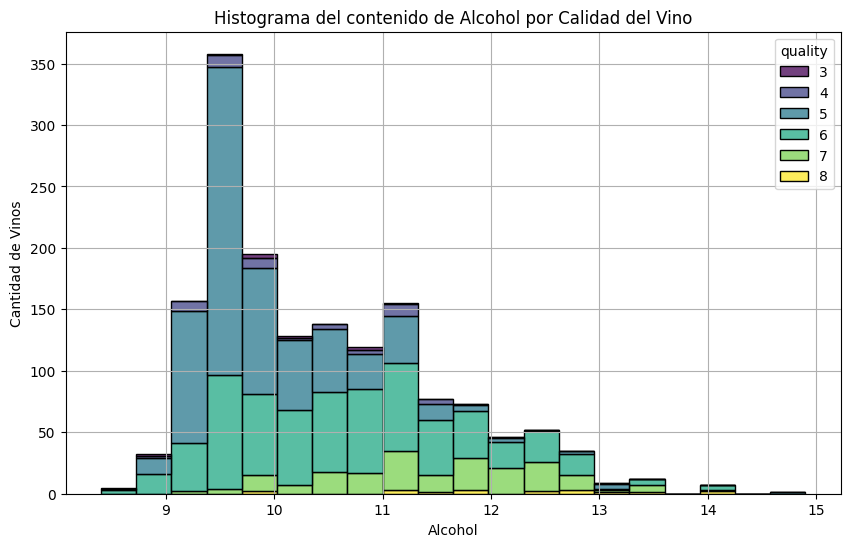

In [18]:
#Aqui tenemos un Histograma de la variable 'alcohol' segmentado por 'quality'
plt.figure(figsize=(10,6))
sns.histplot(data=Datos, x='alcohol', hue='quality', multiple='stack', palette='viridis', bins=20)
plt.title('Histograma del contenido de Alcohol por Calidad del Vino')
plt.xlabel('Alcohol')
plt.ylabel('Cantidad de Vinos')
plt.grid(True)
plt.show()

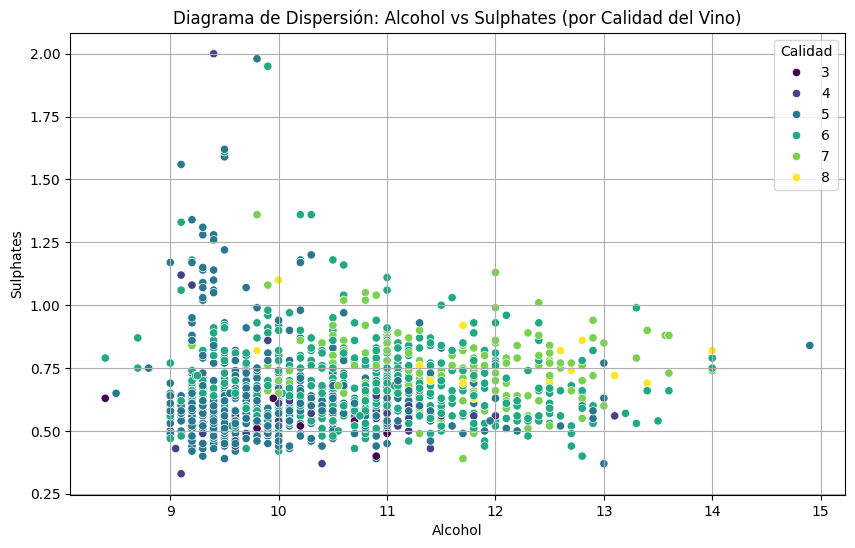

In [17]:
# Diagrama de dispersión: Alcohol vs Sulphates.
plt.figure(figsize=(10,6))
sns.scatterplot(data=Datos, x='alcohol', y='sulphates', hue='quality', palette='viridis')
plt.title('Diagrama de Dispersión: Alcohol vs Sulphates (por Calidad del Vino)')
plt.xlabel('Alcohol')
plt.ylabel('Sulphates')
plt.legend(title='Calidad')
plt.grid(True)
plt.show()

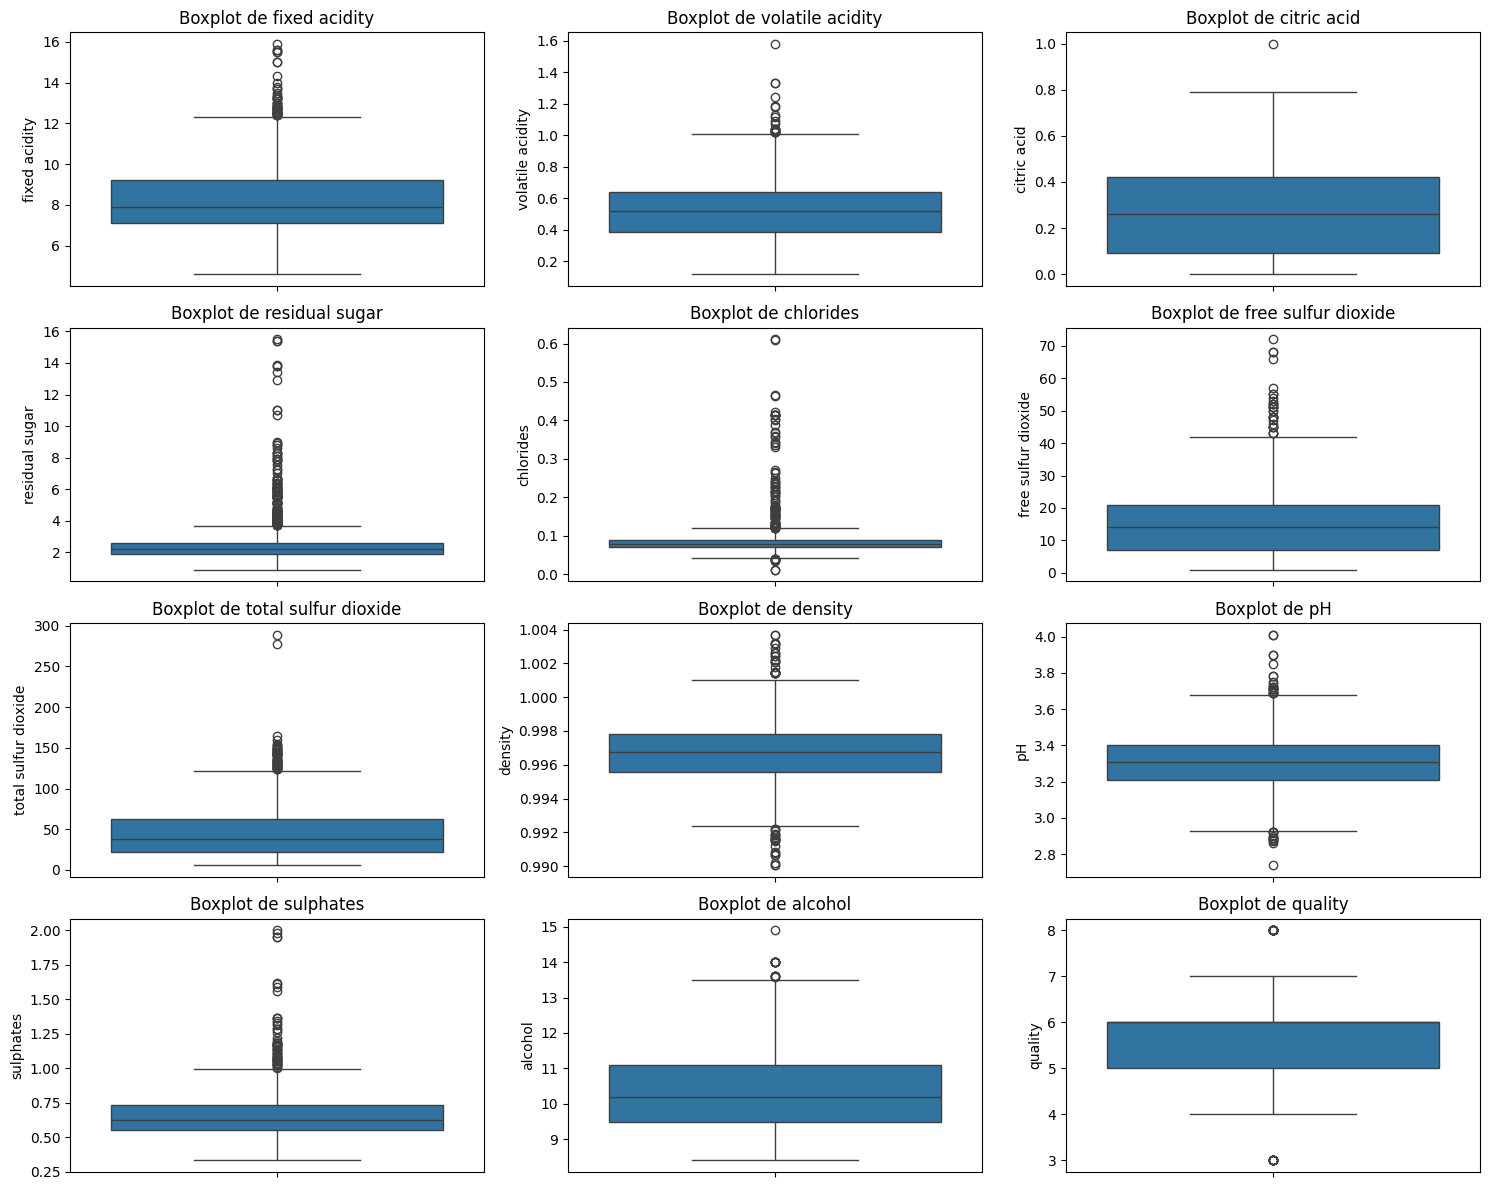

In [24]:
# Visualizar los valores atipico con los boxplots para todas las variables numéricas.
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = Datos.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 12))
for i, columna in enumerate(columnas_numericas, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=Datos[columna])
    plt.title(f'Boxplot de {columna}')
    plt.tight_layout()
plt.show()


In [25]:
target_col = 'quality'
predictor_col = Datos.drop('quality', axis=1).columns

In [28]:
# Aqui se estan Definiendo las variables predictoras y la variable objetivo.
predictors = Datos.drop('quality', axis=1)
target = Datos['quality']

# Aqui se pueden ver las columnas predictoras
predictors.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [29]:
#Aqui se muestran las correlaciones.
corr = predictors.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595


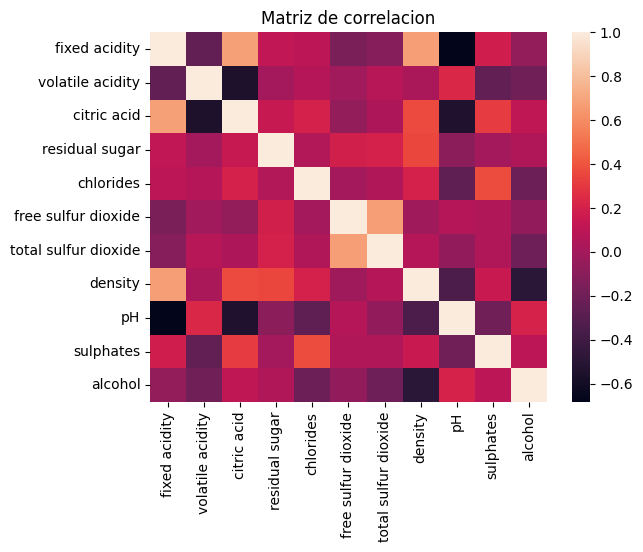

In [30]:
#Matriz de correlacion
sns.heatmap(corr)
plt.title('Matriz de correlacion')
plt.show()

In [49]:
# División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(predictors, target, test_size=0.2, random_state=13)

In [69]:
print(X_train)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
112             8.4             0.600         0.10             2.2      0.085   
889            10.7             0.900         0.34             6.6      0.112   
1229            7.6             0.430         0.29             2.1      0.075   
17              8.1             0.560         0.28             1.7      0.368   
686             7.1             0.650         0.18             1.8      0.070   
...             ...               ...          ...             ...        ...   
742             6.5             0.615         0.00             1.9      0.065   
1552            6.3             0.680         0.01             3.7      0.103   
74              9.7             0.320         0.54             2.5      0.094   
176             7.3             0.380         0.21             2.0      0.080   
338            12.4             0.490         0.58             3.0      0.103   

      free sulfur dioxide  

In [44]:
tree = DecisionTreeClassifier()
arbol = tree.fit(X_train, y_train)
plot_tree(Arbol)

In [70]:
print(X_test)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
912            10.0             0.460         0.44             2.9      0.065   
1391            8.0             0.640         0.22             2.4      0.094   
486            10.2             0.670         0.39             1.9      0.054   
812            10.8             0.450         0.33             2.5      0.099   
980             9.1             0.500         0.30             1.9      0.065   
...             ...               ...          ...             ...        ...   
1432            5.9             0.440         0.00             1.6      0.042   
445             9.5             0.735         0.10             2.1      0.079   
760             9.0             0.580         0.25             2.8      0.075   
420             9.5             0.560         0.33             2.4      0.089   
1238            8.1             0.730         0.00             2.5      0.081   

      free sulfur dioxide  

In [45]:
arbol = tree.fit(X_train, y_train)

[Text(0.5234978262916693, 0.9772727272727273, 'x[10] <= 10.525\ngini = 0.646\nsamples = 1279\nvalue = [9.0, 45.0, 535.0, 514.0, 164.0, 12.0]'),
 Text(0.24511896540900244, 0.9318181818181818, 'x[9] <= 0.535\ngini = 0.546\nsamples = 774\nvalue = [6, 29, 450, 260, 29, 0]'),
 Text(0.3843083958503359, 0.9545454545454546, 'True  '),
 Text(0.043066105844685794, 0.8863636363636364, 'x[1] <= 0.335\ngini = 0.367\nsamples = 183\nvalue = [2, 13, 143, 24, 1, 0]'),
 Text(0.01607131646682152, 0.8409090909090909, 'x[4] <= 0.082\ngini = 0.562\nsamples = 11\nvalue = [0, 1, 4, 6, 0, 0]'),
 Text(0.01205348735011614, 0.7954545454545454, 'x[2] <= 0.375\ngini = 0.406\nsamples = 8\nvalue = [0, 1, 1, 6, 0, 0]'),
 Text(0.00803565823341076, 0.75, 'x[1] <= 0.21\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1, 0, 0, 0]'),
 Text(0.00401782911670538, 0.7045454545454546, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1, 0, 0, 0]'),
 Text(0.01205348735011614, 0.7045454545454546, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0, 0, 0, 

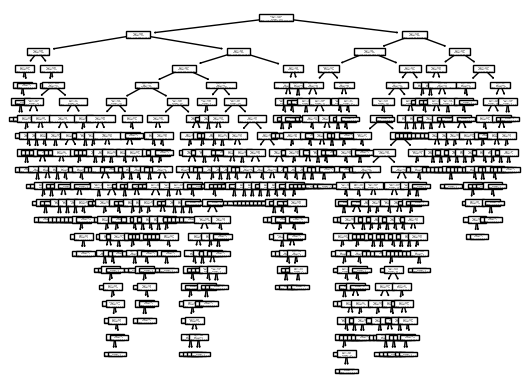

In [47]:
plot_tree(arbol)

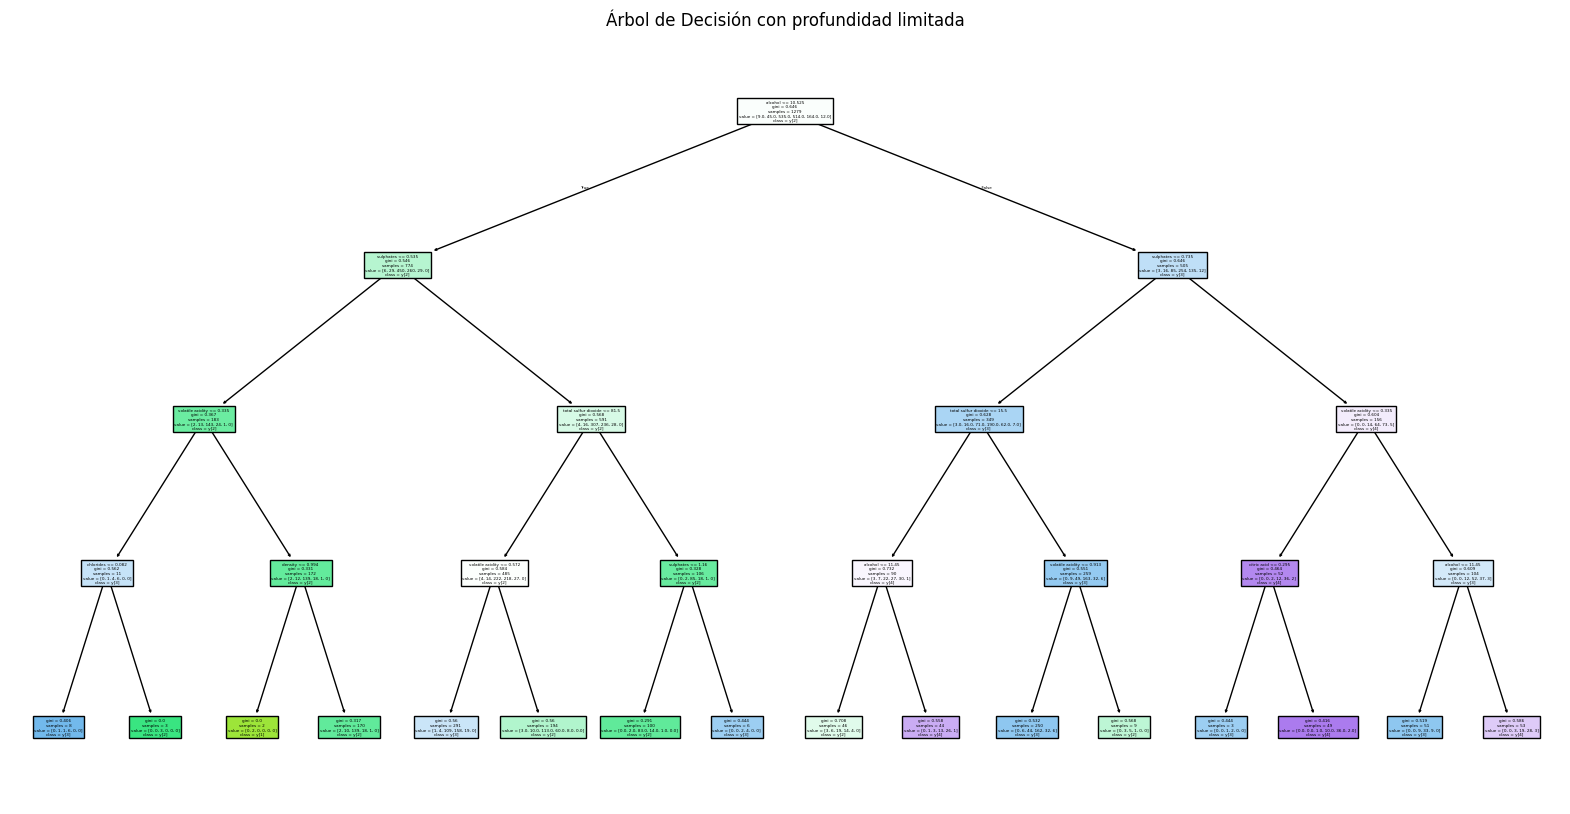

In [51]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Crear el árbol con una profundidad máxima (ej. 3 o 4)
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X_train, y_train)

# Graficar el árbol de forma clara
plt.figure(figsize=(20,10))
plot_tree(arbol, feature_names=predictors.columns, class_names=True, filled=True)
plt.title("Árbol de Decisión con profundidad limitada")
plt.show()


In [54]:
predicciones = arbol.predict(X_test)

In [55]:
predicciones

array([7, 6, 5, 6, 6, 5, 5, 7, 5, 5, 5, 5, 5, 6, 6, 6, 6, 5, 5, 7, 5, 6,
       6, 6, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 6, 6, 6, 5, 5, 6,
       5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 6, 5, 5, 6, 6, 5, 5, 6, 5, 6, 7, 7,
       6, 6, 5, 5, 6, 5, 6, 6, 5, 5, 5, 6, 5, 5, 6, 6, 6, 6, 6, 5, 7, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 7, 6, 6, 5, 5, 7, 6, 5, 6, 6, 7,
       5, 7, 6, 5, 6, 6, 7, 7, 5, 6, 6, 5, 5, 6, 6, 5, 5, 6, 5, 6, 6, 5,
       6, 6, 6, 5, 6, 5, 6, 7, 6, 5, 5, 6, 7, 4, 6, 5, 5, 5, 5, 6, 5, 5,
       6, 5, 5, 5, 6, 5, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5,
       5, 5, 6, 5, 5, 6, 6, 6, 5, 5, 6, 7, 5, 5, 5, 5, 5, 5, 7, 5, 7, 7,
       6, 5, 6, 7, 7, 5, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6, 7, 5, 5, 6, 5, 7,
       5, 5, 6, 6, 6, 5, 5, 5, 5, 6, 5, 6, 6, 6, 5, 5, 6, 5, 6, 5, 6, 6,
       5, 6, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 6, 6, 7, 7, 5, 6, 5, 7, 7, 5,
       6, 5, 5, 6, 5, 5, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 5, 5, 5, 6, 7, 5,
       6, 7, 5, 5, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 6,

In [59]:
pd.crosstab(pd.Series(y_test.tolist()), pd.Series(predicciones), rownames=['Actual'], colnames=['Predicciones'])

Predicciones,4,5,6,7
Actual,,,,
3,0,1,0,0
4,1,6,0,1
5,0,92,52,2
6,0,40,68,16
7,0,3,22,10
8,0,0,4,2


In [62]:
accurracy = accuracy_score(y_test,predicciones)
accuracy

0.7389705882352942

In [63]:
print("Precisión:", precision)
print("Recall:", recall)


Precisión: 0.7392235198521445
Recall: 0.7389705882352942


In [67]:
# Calcular F1-score
f1 = f1_score(y_test, predicciones, average='macro')

print("F1-Score:", f1)


F1-Score: 0.27797418630751963
